In [1]:
import os
import gc
import random
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub


In [2]:
SEED = 42
IMG_SIZE = (224, 224)
AE_BATCH_SIZE = 32
LATENT_DIM = 256

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Use both Kaggle T4 GPUs
strategy = tf.distribute.MirroredStrategy()

# T4 GPUs perform convolution faster with mixed precision
tf.keras.mixed_precision.set_global_policy("mixed_float16")

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("GPUs being used:", strategy.num_replicas_in_sync)
print("Precision policy:", tf.keras.mixed_precision.global_policy())
print("DeepSMOTE image size:", IMG_SIZE)
print("Latent dimensions:", LATENT_DIM)

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPUs being used: 2
Precision policy: <DTypePolicy "mixed_float16">
DeepSMOTE image size: (224, 224)
Latent dimensions: 256


I0000 00:00:1789465180.966779      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789465180.969795      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
DATASET_PATH = Path(
    kagglehub.dataset_download(
        "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
    )
)

IMAGE_DIR = DATASET_PATH / "combined_images"

print("Dataset path:", DATASET_PATH)
print("Image folder:", IMAGE_DIR)
print("Image folder exists:", IMAGE_DIR.exists())

Dataset path: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented
Image folder: /kaggle/input/datasets/aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented/combined_images
Image folder exists: True


In [4]:
class_mapping = {
    "NonDemented": 0,
    "VeryMildDemented": 1,
    "MildDemented": 1,
    "ModerateDemented": 1
}

records = []

for class_name, label in class_mapping.items():
    class_folder = IMAGE_DIR / class_name

    for file_path in sorted(class_folder.iterdir()):
        if file_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "filepath": str(file_path),
                "original_class": class_name,
                "label": label
            })

df = pd.DataFrame(records)

print("Total images:", len(df))

print("\nBinary class counts:")
print(df["label"].value_counts().sort_index())

print("\nOriginal class counts:")
print(df["original_class"].value_counts())

Total images: 44000

Binary class counts:
label
0    12800
1    31200
Name: count, dtype: int64

Original class counts:
original_class
NonDemented         12800
VeryMildDemented    11200
MildDemented        10000
ModerateDemented    10000
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

train_df, temporary_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training:", len(train_df))
print(train_df["label"].value_counts().sort_index())

print("\nValidation:", len(validation_df))
print(validation_df["label"].value_counts().sort_index())

print("\nTesting:", len(test_df))
print(test_df["label"].value_counts().sort_index())

Training: 30800
label
0     8960
1    21840
Name: count, dtype: int64

Validation: 6600
label
0    1920
1    4680
Name: count, dtype: int64

Testing: 6600
label
0    1920
1    4680
Name: count, dtype: int64


In [6]:
AUTOTUNE = tf.data.AUTOTUNE

def load_mri(file_path, label):
    image_bytes = tf.io.read_file(file_path)

    image = tf.io.decode_image(
        image_bytes,
        channels=1,
        expand_animations=False
    )
    image.set_shape([None, None, 1])

    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )
    image = tf.image.resize(
        image,
        IMG_SIZE,
        method="bilinear"
    )

    return image, tf.cast(label, tf.int32)


def make_image_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].to_numpy(),
        dataframe["label"].to_numpy()
    ))

    # Shuffle file paths before loading images to save RAM
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_mri,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        AE_BATCH_SIZE,
        drop_remainder=False
    )

    return dataset.prefetch(AUTOTUNE)


train_image_ds = make_image_dataset(
    train_df,
    training=True
)

validation_image_ds = make_image_dataset(
    validation_df
)

test_image_ds = make_image_dataset(
    test_df
)

sample_images, sample_labels = next(iter(train_image_ds))

print("Image batch shape:", sample_images.shape)
print("Label batch shape:", sample_labels.shape)
print("Pixel range:",
      float(tf.reduce_min(sample_images)),
      "to",
      float(tf.reduce_max(sample_images)))
print("First labels:", sample_labels[:10].numpy())

Image batch shape: (32, 224, 224, 1)
Label batch shape: (32,)
Pixel range: 0.0 to 1.0
First labels: [0 1 0 0 1 1 0 1 0 1]


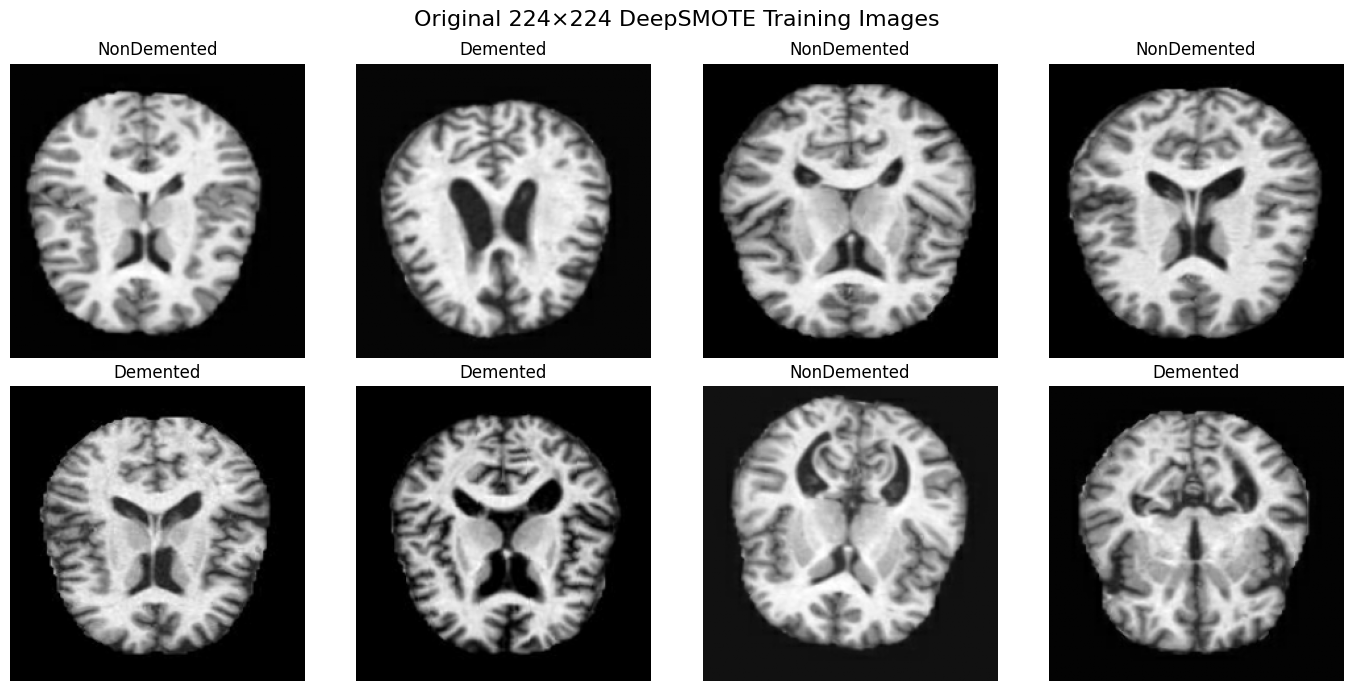

In [7]:
class_names = {
    0: "NonDemented",
    1: "Demented"
}

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for axis, image, label in zip(
    axes.flat,
    sample_images[:8],
    sample_labels[:8]
):
    axis.imshow(
        tf.squeeze(image),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axis.set_title(class_names[int(label)])
    axis.axis("off")

plt.suptitle(
    "Original 224×224 DeepSMOTE Training Images",
    fontsize=16
)
plt.tight_layout()
plt.show()

In [8]:
AE_EPOCHS = 100
AE_PATIENCE = 8
AE_LEARNING_RATE = 2e-4

LATENT_DIM = 300
RECONSTRUCTION_WEIGHT = 1.0
PENALTY_WEIGHT = 1.0

print("Method: Original-style DeepSMOTE baseline")
print("Image size:", IMG_SIZE)
print("Batch size:", AE_BATCH_SIZE)
print("Latent dimensions:", LATENT_DIM)
print("Maximum epochs:", AE_EPOCHS)
print("Early-stopping patience:", AE_PATIENCE)
print("Learning rate:", AE_LEARNING_RATE)
print("Reconstruction loss: MSE")
print("Reconstruction weight:", RECONSTRUCTION_WEIGHT)
print("Same-class penalty: MSE")
print("Penalty weight:", PENALTY_WEIGHT)

Method: Original-style DeepSMOTE baseline
Image size: (224, 224)
Batch size: 32
Latent dimensions: 300
Maximum epochs: 100
Early-stopping patience: 8
Learning rate: 0.0002
Reconstruction loss: MSE
Reconstruction weight: 1.0
Same-class penalty: MSE
Penalty weight: 1.0


In [9]:
tf.keras.backend.clear_session()

def build_encoder():
    inputs = tf.keras.Input(
        shape=(224, 224, 1),
        name="encoder_input"
    )

    x = inputs

    for layer_number, filters in enumerate(
        [64, 128, 256, 512, 512]
    ):
        x = tf.keras.layers.Conv2D(
            filters,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.02
            ),
            name=f"encoder_conv_{layer_number + 1}"
        )(x)

        if layer_number > 0:
            x = tf.keras.layers.BatchNormalization(
                name=f"encoder_bn_{layer_number + 1}"
            )(x)

        x = tf.keras.layers.LeakyReLU(
            negative_slope=0.2,
            name=f"encoder_leakyrelu_{layer_number + 1}"
        )(x)

    x = tf.keras.layers.Flatten(name="encoder_flatten")(x)

    latent = tf.keras.layers.Dense(
        LATENT_DIM,
        activation=None,
        dtype="float32",
        name="latent_vector"
    )(x)

    return tf.keras.Model(
        inputs,
        latent,
        name="DeepSMOTE_Encoder"
    )


with strategy.scope():
    encoder = build_encoder()

print("Encoder output shape:", encoder.output_shape)
print("Encoder parameters:", encoder.count_params())

encoder.summary()

Encoder output shape: (None, 300)
Encoder parameters: 14480172


Model: "DeepSMOTE_Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_1 (Conv2D)         │ (None, 112, 112, 64)   │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_1 (LeakyReLU) │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_2 (Conv2D)         │ (None, 56, 56, 128)    │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_2                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_2 (LeakyReLU) │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_3 (Conv2D)         │ (None, 28, 28, 256)    │       524,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_3                    │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_3 (LeakyReLU) │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_4 (Conv2D)         │ (None, 14, 14, 512)    │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_4                    │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_4 (LeakyReLU) │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv_5 (Conv2D)         │ (None, 7, 7, 512)      │     4,194,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_bn_5                    │ (None, 7, 7, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_leakyrelu_5 (LeakyReLU) │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_flatten (Flatten)       │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 300)            │     7,526,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,480,172 (55.24 MB)

 Trainable params: 14,477,356 (55.23 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [10]:
def build_decoder():
    latent_inputs = tf.keras.Input(
        shape=(LATENT_DIM,),
        name="decoder_latent_input"
    )

    x = tf.keras.layers.Dense(
        7 * 7 * 512,
        use_bias=False,
        name="decoder_dense"
    )(latent_inputs)

    x = tf.keras.layers.Reshape(
        (7, 7, 512),
        name="decoder_reshape"
    )(x)

    decoder_filters = [512, 256, 128, 64]

    for layer_number, filters in enumerate(decoder_filters):
        x = tf.keras.layers.Conv2DTranspose(
            filters,
            kernel_size=4,
            strides=2,
            padding="same",
            use_bias=False,
            kernel_initializer=tf.keras.initializers.RandomNormal(
                mean=0.0,
                stddev=0.02
            ),
            name=f"decoder_transpose_{layer_number + 1}"
        )(x)

        x = tf.keras.layers.BatchNormalization(
            name=f"decoder_bn_{layer_number + 1}"
        )(x)

        x = tf.keras.layers.ReLU(
            name=f"decoder_relu_{layer_number + 1}"
        )(x)

    outputs = tf.keras.layers.Conv2DTranspose(
        1,
        kernel_size=4,
        strides=2,
        padding="same",
        activation="tanh",
        dtype="float32",
        kernel_initializer=tf.keras.initializers.RandomNormal(
            mean=0.0,
            stddev=0.02
        ),
        name="decoder_output"
    )(x)

    return tf.keras.Model(
        latent_inputs,
        outputs,
        name="DeepSMOTE_Decoder"
    )


with strategy.scope():
    decoder = build_decoder()

print("Decoder input shape:", decoder.input_shape)
print("Decoder output shape:", decoder.output_shape)
print("Decoder parameters:", decoder.count_params())

decoder.summary()

Decoder input shape: (None, 300)
Decoder output shape: (None, 224, 224, 1)
Decoder parameters: 14478081


Model: "DeepSMOTE_Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_latent_input            │ (None, 300)            │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense (Dense)           │ (None, 25088)          │     7,526,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_reshape (Reshape)       │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_transpose_1             │ (None, 14, 14, 512)    │     4,194,304 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_1                    │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_1 (ReLU)           │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_transpose_2             │ (None, 28, 28, 256)    │     2,097,152 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_2                    │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_2 (ReLU)           │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_transpose_3             │ (None, 56, 56, 128)    │       524,288 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_3                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_3 (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_transpose_4             │ (None, 112, 112, 64)   │       131,072 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_bn_4                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_relu_4 (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output                  │ (None, 224, 224, 1)    │         1,025 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,478,081 (55.23 MB)

 Trainable params: 14,476,161 (55.22 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [11]:
def make_repeated_class_dataset(class_dataframe):
    dataset = tf.data.Dataset.from_tensor_slices((
        class_dataframe["filepath"].to_numpy(),
        class_dataframe["label"].to_numpy()
    ))

    dataset = dataset.shuffle(
        buffer_size=len(class_dataframe),
        seed=SEED,
        reshuffle_each_iteration=True
    )

    dataset = dataset.repeat()

    dataset = dataset.map(
        load_mri,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        AE_BATCH_SIZE,
        drop_remainder=True
    )

    return dataset.prefetch(AUTOTUNE)


class_0_df = train_df[train_df["label"] == 0]
class_1_df = train_df[train_df["label"] == 1]

class_0_penalty_ds = make_repeated_class_dataset(class_0_df)
class_1_penalty_ds = make_repeated_class_dataset(class_1_df)

# Each selected batch comes entirely from one class
penalty_ds = tf.data.Dataset.sample_from_datasets(
    [class_0_penalty_ds, class_1_penalty_ds],
    weights=[0.5, 0.5],
    seed=SEED
)

# First item: normal reconstruction batch
# Second item: same-class penalty batch
deep_smote_train_ds = tf.data.Dataset.zip((
    train_image_ds,
    penalty_ds
))

normal_batch, penalty_batch = next(
    iter(deep_smote_train_ds)
)

normal_images, normal_labels = normal_batch
penalty_images, penalty_labels = penalty_batch

print("Normal image batch:", normal_images.shape)
print("Normal batch classes:",
      np.unique(normal_labels.numpy()))

print("Penalty image batch:", penalty_images.shape)
print("Penalty batch classes:",
      np.unique(penalty_labels.numpy()))

print("Class 0 training images:", len(class_0_df))
print("Class 1 training images:", len(class_1_df))

Normal image batch: (32, 224, 224, 1)
Normal batch classes: [0 1]
Penalty image batch: (32, 224, 224, 1)
Penalty batch classes: [0]
Class 0 training images: 8960
Class 1 training images: 21840


In [12]:
class DeepSMOTETrainer(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super().__init__(name="DeepSMOTE_Trainer")

        self.encoder = encoder
        self.decoder = decoder

        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.penalty_tracker = tf.keras.metrics.Mean(
            name="penalty_loss"
        )

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.reconstruction_tracker,
            self.penalty_tracker
        ]

    def scale_images(self, images):
        # Dataset range 0–1 → tanh-compatible range -1–1
        images = tf.cast(images, tf.float32)
        return (images * 2.0) - 1.0

    def call(self, images, training=False):
        images = self.scale_images(images)
        latent = self.encoder(images, training=training)
        return self.decoder(latent, training=training)

    def train_step(self, data):
        normal_batch, penalty_batch = data
        normal_images, _ = normal_batch
        penalty_images, _ = penalty_batch

        normal_images = self.scale_images(normal_images)
        penalty_images = self.scale_images(penalty_images)

        with tf.GradientTape() as tape:
            # Standard reconstruction
            normal_latent = self.encoder(
                normal_images,
                training=True
            )
            reconstructed = self.decoder(
                normal_latent,
                training=True
            )

            reconstruction_loss = tf.reduce_mean(
                tf.square(normal_images - reconstructed)
            )

            # Same-class DeepSMOTE penalty
            penalty_latent = self.encoder(
                penalty_images,
                training=True
            )

            permutation = tf.random.shuffle(
                tf.range(tf.shape(penalty_latent)[0])
            )

            permuted_latent = tf.gather(
                penalty_latent,
                permutation
            )
            permuted_targets = tf.gather(
                penalty_images,
                permutation
            )

            penalty_reconstruction = self.decoder(
                permuted_latent,
                training=True
            )

            penalty_loss = tf.reduce_mean(
                tf.square(
                    permuted_targets -
                    penalty_reconstruction
                )
            )

            total_loss = (
                RECONSTRUCTION_WEIGHT * reconstruction_loss +
                PENALTY_WEIGHT * penalty_loss
            )

            # Required for mixed-float16 training
            scaled_loss = self.optimizer.scale_loss(total_loss)

        trainable_variables = (
            self.encoder.trainable_variables +
            self.decoder.trainable_variables
        )

        gradients = tape.gradient(
            scaled_loss,
            trainable_variables
        )

        self.optimizer.apply_gradients(
            zip(gradients, trainable_variables)
        )

        self.loss_tracker.update_state(total_loss)
        self.reconstruction_tracker.update_state(
            reconstruction_loss
        )
        self.penalty_tracker.update_state(penalty_loss)

        return {
            "loss": self.loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_tracker.result(),
            "penalty_loss": self.penalty_tracker.result()
        }

    def test_step(self, data):
        images, _ = data
        images = self.scale_images(images)

        latent = self.encoder(images, training=False)
        reconstructed = self.decoder(latent, training=False)

        reconstruction_loss = tf.reduce_mean(
            tf.square(images - reconstructed)
        )

        self.loss_tracker.update_state(reconstruction_loss)
        self.reconstruction_tracker.update_state(
            reconstruction_loss
        )
        self.penalty_tracker.update_state(0.0)

        return {
            "loss": self.loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_tracker.result(),
            "penalty_loss": self.penalty_tracker.result()
        }


with strategy.scope():
    deep_smote_model = DeepSMOTETrainer(
        encoder,
        decoder
    )

    deep_smote_model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=AE_LEARNING_RATE
        )
    )

preview_output = deep_smote_model(
    sample_images[:2],
    training=False
)

print("Untrained reconstruction shape:",
      preview_output.shape)
print("Output range:",
      float(tf.reduce_min(preview_output)),
      "to",
      float(tf.reduce_max(preview_output)))

Untrained reconstruction shape: (2, 224, 224, 1)
Output range: -0.00023551790218334645 to 0.00017302457126788795


In [13]:
generator_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=AE_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "/kaggle/working/deepsmote_baseline_best.weights.h5",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]

generator_history = deep_smote_model.fit(
    deep_smote_train_ds,
    validation_data=validation_image_ds,
    epochs=AE_EPOCHS,
    callbacks=generator_callbacks,
    verbose=1
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

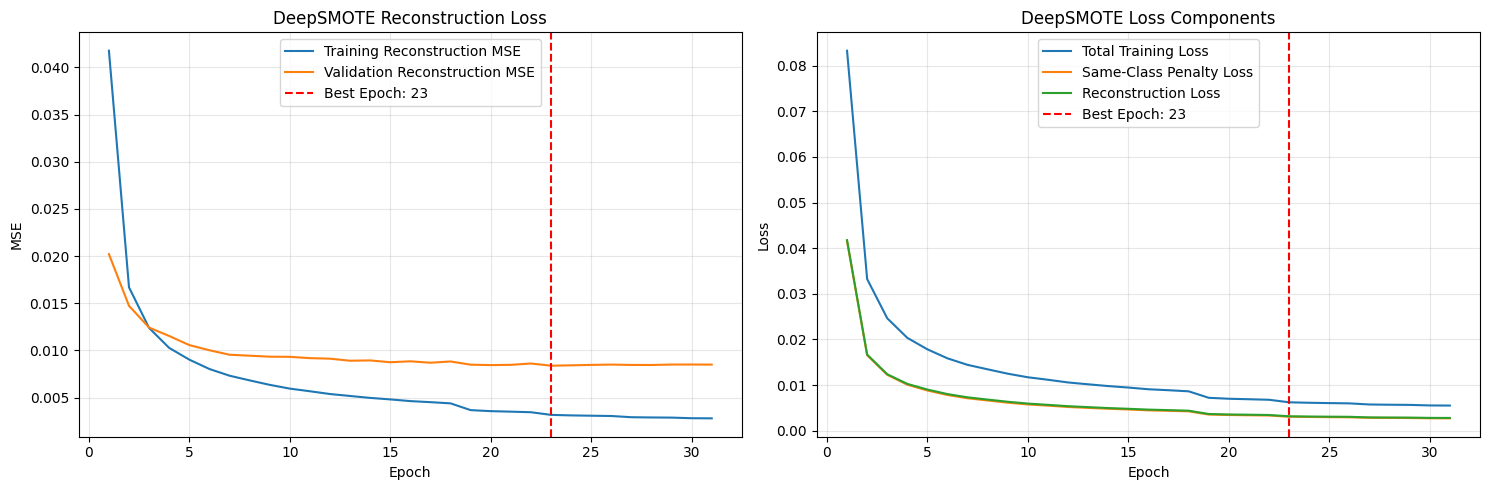

Epochs completed: 31
Best epoch: 23
Best validation reconstruction loss: 0.008381


In [14]:
best_epoch = np.argmin(
    generator_history.history["val_loss"]
) + 1

epochs = range(
    1,
    len(generator_history.history["loss"]) + 1
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Comparable reconstruction losses
axes[0].plot(
    epochs,
    generator_history.history["reconstruction_loss"],
    label="Training Reconstruction MSE"
)
axes[0].plot(
    epochs,
    generator_history.history["val_reconstruction_loss"],
    label="Validation Reconstruction MSE"
)
axes[0].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[0].set_title("DeepSMOTE Reconstruction Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

# DeepSMOTE training components
axes[1].plot(
    epochs,
    generator_history.history["loss"],
    label="Total Training Loss"
)
axes[1].plot(
    epochs,
    generator_history.history["penalty_loss"],
    label="Same-Class Penalty Loss"
)
axes[1].plot(
    epochs,
    generator_history.history["reconstruction_loss"],
    label="Reconstruction Loss"
)
axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[1].set_title("DeepSMOTE Loss Components")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Epochs completed:",
      len(generator_history.history["loss"]))
print("Best epoch:", best_epoch)
print("Best validation reconstruction loss:",
      round(min(generator_history.history["val_loss"]), 6))

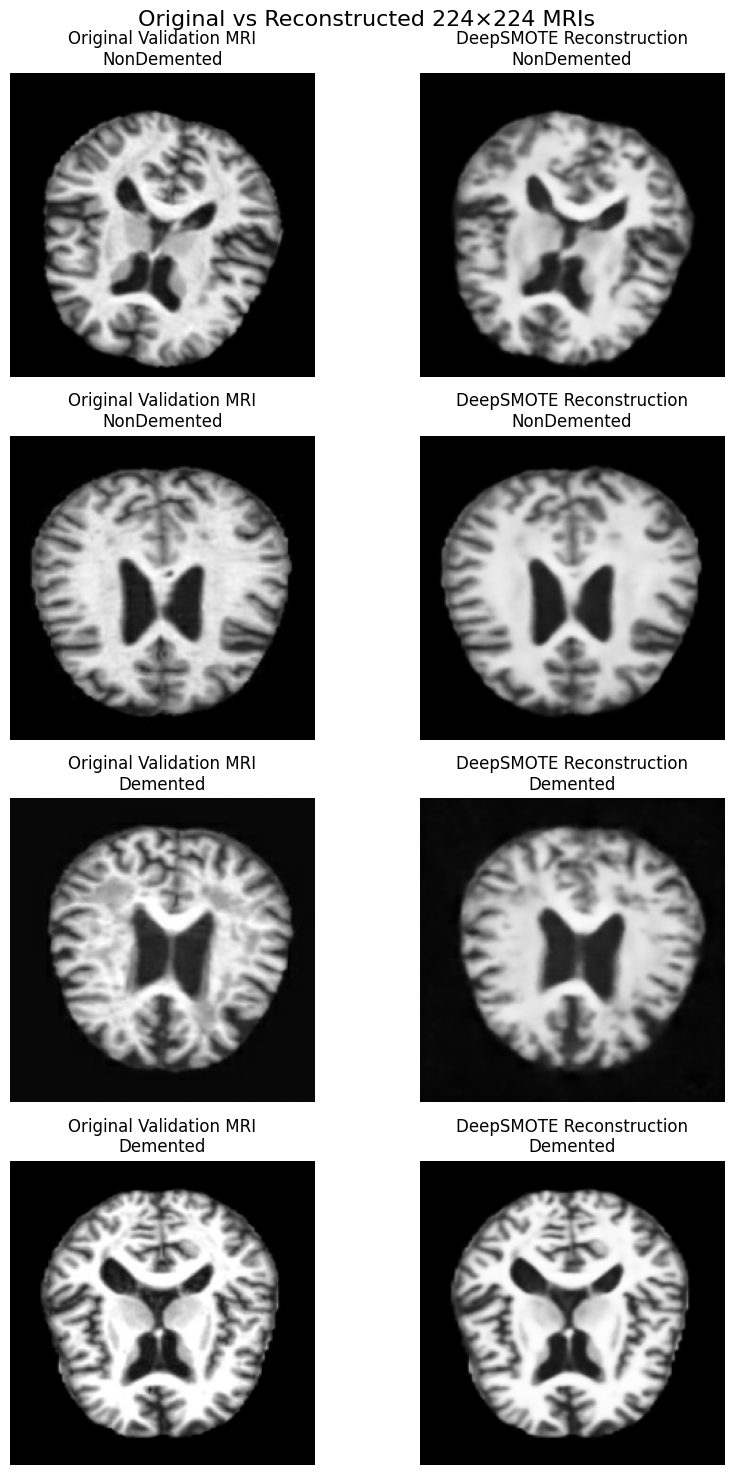

Original range: 0.0 to 1.0
Reconstructed range: 1.7881393432617188e-07 to 0.9956865310668945


In [15]:
validation_images, validation_labels = next(
    iter(validation_image_ds)
)

reconstructed_tanh = deep_smote_model(
    validation_images[:4],
    training=False
)

# Decoder range -1–1 → display range 0–1
reconstructed_images = tf.clip_by_value(
    (reconstructed_tanh + 1.0) / 2.0,
    0.0,
    1.0
)

fig, axes = plt.subplots(4, 2, figsize=(9, 15))

for row in range(4):
    label_name = (
        "Demented"
        if int(validation_labels[row]) == 1
        else "NonDemented"
    )

    axes[row, 0].imshow(
        tf.squeeze(validation_images[row]),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].set_title(
        f"Original Validation MRI\n{label_name}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        tf.squeeze(reconstructed_images[row]),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 1].set_title(
        f"DeepSMOTE Reconstruction\n{label_name}"
    )
    axes[row, 1].axis("off")

plt.suptitle(
    "Original vs Reconstructed 224×224 MRIs",
    fontsize=16
)
plt.tight_layout()
plt.show()

print("Original range:",
      float(tf.reduce_min(validation_images[:4])),
      "to",
      float(tf.reduce_max(validation_images[:4])))

print("Reconstructed range:",
      float(tf.reduce_min(reconstructed_images)),
      "to",
      float(tf.reduce_max(reconstructed_images)))

In [16]:
all_mse = []
all_ssim = []
all_psnr = []
all_edge_ratios = []

print("Evaluating reconstruction quality...")

for images, _ in validation_image_ds:
    reconstructed_tanh = deep_smote_model(
        images,
        training=False
    )

    reconstructed = tf.clip_by_value(
        (reconstructed_tanh + 1.0) / 2.0,
        0.0,
        1.0
    )

    # Pixel reconstruction error
    mse = tf.reduce_mean(
        tf.square(images - reconstructed),
        axis=[1, 2, 3]
    )

    # Structural and signal-quality metrics
    ssim = tf.image.ssim(
        images,
        reconstructed,
        max_val=1.0
    )

    psnr = tf.image.psnr(
        images,
        reconstructed,
        max_val=1.0
    )

    # Edge strength comparison
    original_edges = tf.image.sobel_edges(images)
    reconstructed_edges = tf.image.sobel_edges(reconstructed)

    original_edge_energy = tf.reduce_mean(
        tf.abs(original_edges),
        axis=[1, 2, 3, 4]
    )

    reconstructed_edge_energy = tf.reduce_mean(
        tf.abs(reconstructed_edges),
        axis=[1, 2, 3, 4]
    )

    edge_ratio = reconstructed_edge_energy / (
        original_edge_energy + 1e-8
    )

    all_mse.append(mse.numpy())
    all_ssim.append(ssim.numpy())
    all_psnr.append(psnr.numpy())
    all_edge_ratios.append(edge_ratio.numpy())


all_mse = np.concatenate(all_mse)
all_ssim = np.concatenate(all_ssim)
all_psnr = np.concatenate(all_psnr)
all_edge_ratios = np.concatenate(all_edge_ratios)

print("Validation images evaluated:", len(all_mse))
print("Mean MSE:", round(all_mse.mean(), 6))
print("Mean SSIM:", round(all_ssim.mean(), 4))
print("Mean PSNR:", round(all_psnr.mean(), 2), "dB")
print("Mean edge-retention ratio:",
      round(all_edge_ratios.mean(), 4))

print("\nSSIM standard deviation:",
      round(all_ssim.std(), 4))
print("Minimum SSIM:",
      round(all_ssim.min(), 4))
print("Maximum SSIM:",
      round(all_ssim.max(), 4))

Evaluating reconstruction quality...
Validation images evaluated: 6600
Mean MSE: 0.0021
Mean SSIM: 0.8777
Mean PSNR: 28.81 dB
Mean edge-retention ratio: 0.896

SSIM standard deviation: 0.0739
Minimum SSIM: 0.659
Maximum SSIM: 0.9838


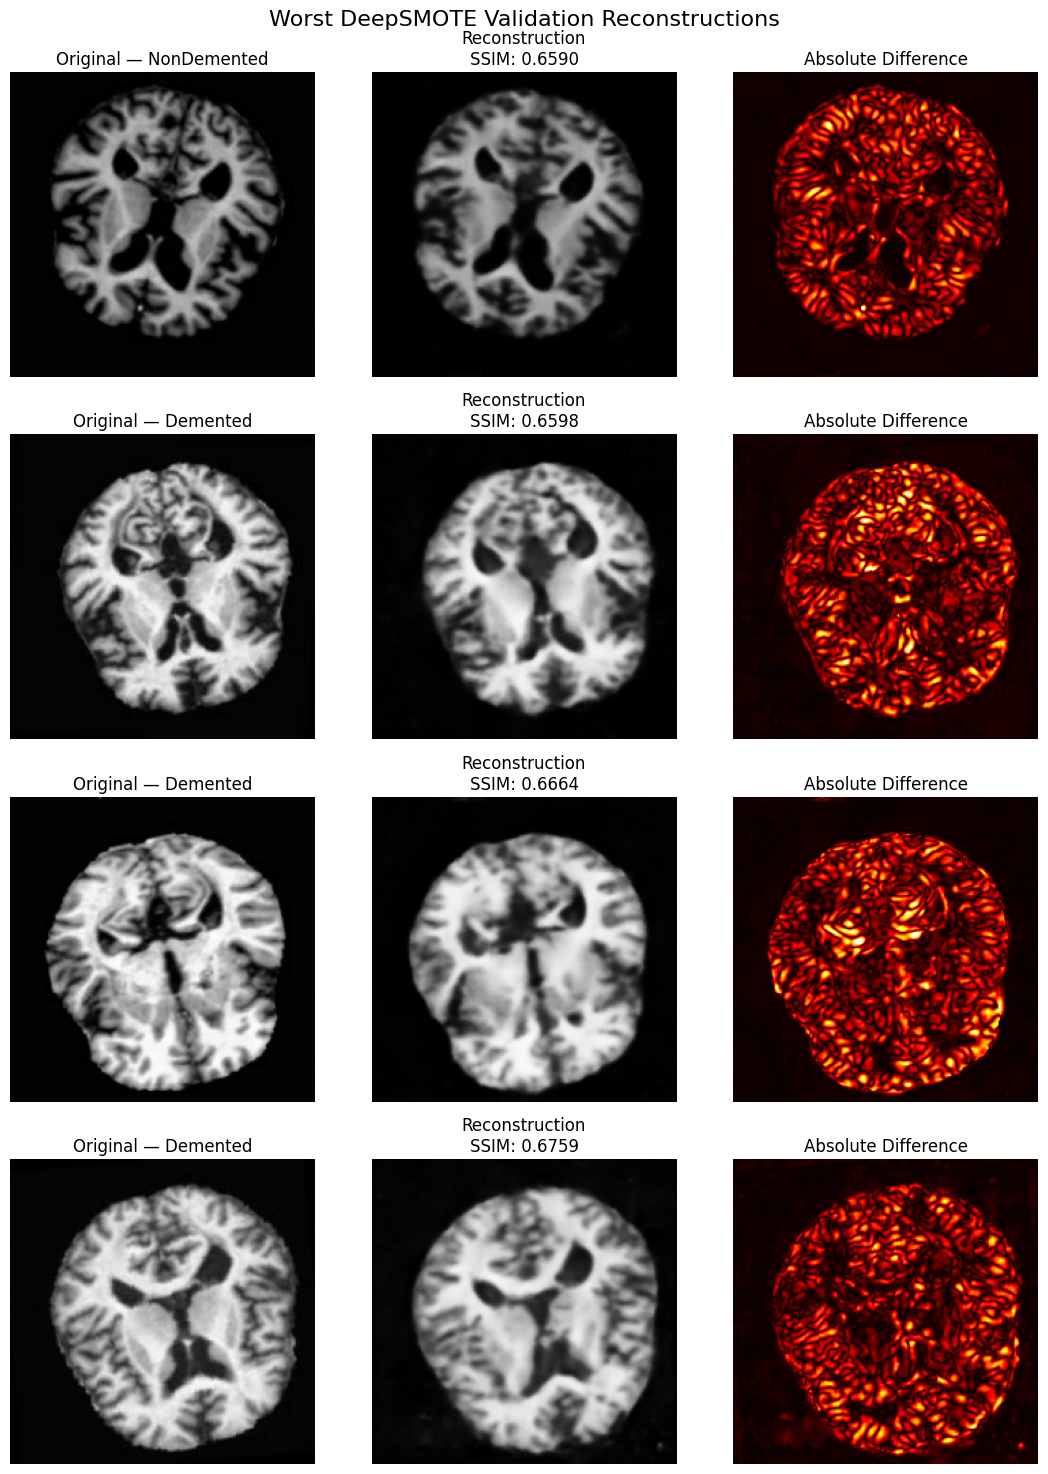

Worst validation indices: [1865 5102 4626 5601]
Worst SSIM values: [0.659  0.6598 0.6664 0.6759]


In [17]:
worst_indices = np.argsort(all_ssim)[:4]

worst_df = validation_df.iloc[
    worst_indices
].reset_index(drop=True)

worst_ds = make_image_dataset(worst_df)
worst_images, worst_labels = next(iter(worst_ds))

worst_reconstructed_tanh = deep_smote_model(
    worst_images,
    training=False
)

worst_reconstructed = tf.clip_by_value(
    (worst_reconstructed_tanh + 1.0) / 2.0,
    0.0,
    1.0
)

fig, axes = plt.subplots(4, 3, figsize=(11, 15))

for row in range(4):
    original = tf.squeeze(worst_images[row])
    reconstructed = tf.squeeze(worst_reconstructed[row])
    difference = tf.abs(original - reconstructed)

    label_name = (
        "Demented"
        if int(worst_labels[row]) == 1
        else "NonDemented"
    )

    axes[row, 0].imshow(
        original,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].set_title(
        f"Original — {label_name}"
    )

    axes[row, 1].imshow(
        reconstructed,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 1].set_title(
        f"Reconstruction\n"
        f"SSIM: {all_ssim[worst_indices[row]]:.4f}"
    )

    axes[row, 2].imshow(
        difference,
        cmap="hot",
        vmin=0,
        vmax=0.5
    )
    axes[row, 2].set_title("Absolute Difference")

    for column in range(3):
        axes[row, column].axis("off")

plt.suptitle(
    "Worst DeepSMOTE Validation Reconstructions",
    fontsize=16
)
plt.tight_layout()
plt.show()

print("Worst validation indices:", worst_indices)
print("Worst SSIM values:",
      np.round(all_ssim[worst_indices], 4))

In [18]:
validation_labels_array = validation_df[
    "label"
].to_numpy()

quality_results = pd.DataFrame({
    "Class": np.where(
        validation_labels_array == 0,
        "NonDemented",
        "Demented"
    ),
    "MSE": all_mse,
    "SSIM": all_ssim,
    "PSNR": all_psnr,
    "Edge Retention": all_edge_ratios
})

quality_summary = quality_results.groupby(
    "Class"
).agg({
    "MSE": ["mean", "median"],
    "SSIM": ["mean", "median", "min"],
    "PSNR": ["mean", "median"],
    "Edge Retention": ["mean", "median"]
})

display(quality_summary.round(4))

for class_name in ["NonDemented", "Demented"]:
    class_quality = quality_results[
        quality_results["Class"] == class_name
    ]

    print(f"\n{class_name}")
    print("Images:", len(class_quality))
    print(
        "SSIM below 0.80:",
        round(
            100 * np.mean(class_quality["SSIM"] < 0.80),
            2
        ),
        "%"
    )
    print(
        "Edge retention below 0.80:",
        round(
            100 * np.mean(
                class_quality["Edge Retention"] < 0.80
            ),
            2
        ),
        "%"
    )

MSE            SSIM                       PSNR             \
               mean  median    mean  median     min       mean     median   
Class                                                                       
Demented     0.0022  0.0012  0.8767  0.9060  0.6598  28.872200  29.245899   
NonDemented  0.0019  0.0011  0.8800  0.9094  0.6590  28.665199  29.720900   

            Edge Retention          
                      mean  median  
Class                               
Demented            0.8979  0.8937  
NonDemented         0.8913  0.8914


NonDemented
Images: 1920
SSIM below 0.80: 19.74 %
Edge retention below 0.80: 0.99 %

Demented
Images: 4680
SSIM below 0.80: 23.68 %
Edge retention below 0.80: 1.65 %


In [19]:
deterministic_train_ds = make_image_dataset(
    train_df,
    training=False
)

with strategy.scope():
    latent_input = tf.keras.Input(
        shape=(224, 224, 1),
        name="latent_extraction_input"
    )

    scaled_input = tf.keras.layers.Rescaling(
        scale=2.0,
        offset=-1.0,
        name="scale_to_tanh_range"
    )(latent_input)

    latent_output = encoder(
        scaled_input,
        training=False
    )

    latent_extractor = tf.keras.Model(
        latent_input,
        latent_output,
        name="DeepSMOTE_Latent_Extractor"
    )

print("Extracting training latent vectors...")

training_latent_vectors = latent_extractor.predict(
    deterministic_train_ds,
    verbose=1
)

training_latent_labels = train_df[
    "label"
].to_numpy(dtype=np.int32)

print("Latent feature shape:",
      training_latent_vectors.shape)
print("Label shape:",
      training_latent_labels.shape)
print("Class counts:",
      Counter(training_latent_labels))
print("NaN values:",
      np.isnan(training_latent_vectors).sum())
print("Infinite values:",
      np.isinf(training_latent_vectors).sum())

np.save(
    "/kaggle/working/deepsmote_training_latent_vectors.npy",
    training_latent_vectors
)
np.save(
    "/kaggle/working/deepsmote_training_labels.npy",
    training_latent_labels
)

print("Training latent vectors saved.")

Extracting training latent vectors...
963/963 ━━━━━━━━━━━━━━━━━━━━ 47s 49ms/step
Latent feature shape: (30800, 300)
Label shape: (30800,)
Class counts: Counter({np.int32(1): 21840, np.int32(0): 8960})
NaN values: 0
Infinite values: 0
Training latent vectors saved.


In [20]:
from imblearn.over_sampling import SMOTE

latent_smote = SMOTE(
    sampling_strategy="auto",
    random_state=SEED,
    k_neighbors=5
)

print("Before latent SMOTE:",
      Counter(training_latent_labels))

balanced_latent_vectors, balanced_latent_labels = (
    latent_smote.fit_resample(
        training_latent_vectors,
        training_latent_labels
    )
)

ORIGINAL_TRAINING_COUNT = len(
    training_latent_vectors
)

synthetic_latent_vectors = balanced_latent_vectors[
    ORIGINAL_TRAINING_COUNT:
].astype(np.float32)

synthetic_latent_labels = balanced_latent_labels[
    ORIGINAL_TRAINING_COUNT:
].astype(np.int32)

print("After latent SMOTE:",
      Counter(balanced_latent_labels))
print("Balanced latent shape:",
      balanced_latent_vectors.shape)
print("Synthetic latent shape:",
      synthetic_latent_vectors.shape)
print("Synthetic labels:",
      Counter(synthetic_latent_labels))
print("Synthetic vectors finite:",
      np.isfinite(synthetic_latent_vectors).all())

assert synthetic_latent_vectors.shape == (12880, LATENT_DIM)
assert np.all(synthetic_latent_labels == 0)
assert np.isfinite(synthetic_latent_vectors).all()

np.save(
    "/kaggle/working/deepsmote_synthetic_latent_vectors.npy",
    synthetic_latent_vectors
)

print("Synthetic latent vectors saved.")

Before latent SMOTE: Counter({np.int32(1): 21840, np.int32(0): 8960})
After latent SMOTE: Counter({np.int32(1): 21840, np.int32(0): 21840})
Balanced latent shape: (43680, 300)
Synthetic latent shape: (12880, 300)
Synthetic labels: Counter({np.int32(0): 12880})
Synthetic vectors finite: True
Synthetic latent vectors saved.


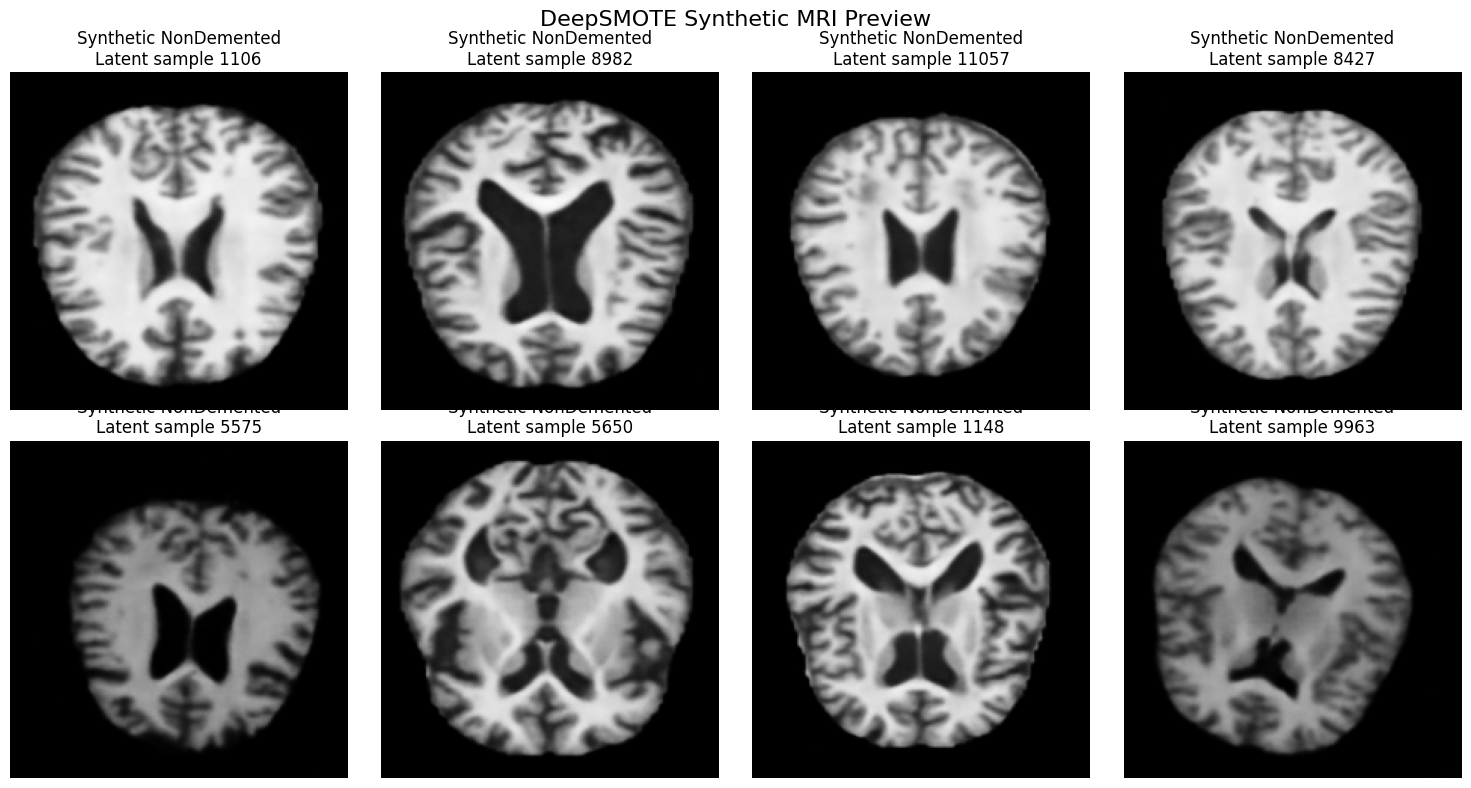

Preview shape: (8, 224, 224, 1)
Pixel range: 3.5762787e-07 to 0.9809803
NaN values: 0
Infinite values: 0


In [21]:
rng = np.random.default_rng(SEED)

preview_indices = rng.choice(
    len(synthetic_latent_vectors),
    size=8,
    replace=False
)

preview_latent = synthetic_latent_vectors[
    preview_indices
]

preview_tanh = decoder.predict(
    preview_latent,
    batch_size=8,
    verbose=0
)

preview_images = np.clip(
    (preview_tanh + 1.0) / 2.0,
    0.0,
    1.0
)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for axis, image, index in zip(
    axes.flat,
    preview_images,
    preview_indices
):
    axis.imshow(
        image[:, :, 0],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axis.set_title(
        f"Synthetic NonDemented\nLatent sample {index}"
    )
    axis.axis("off")

plt.suptitle(
    "DeepSMOTE Synthetic MRI Preview",
    fontsize=16
)
plt.tight_layout()
plt.show()

print("Preview shape:", preview_images.shape)
print("Pixel range:",
      preview_images.min(),
      "to",
      preview_images.max())
print("NaN values:", np.isnan(preview_images).sum())
print("Infinite values:", np.isinf(preview_images).sum())

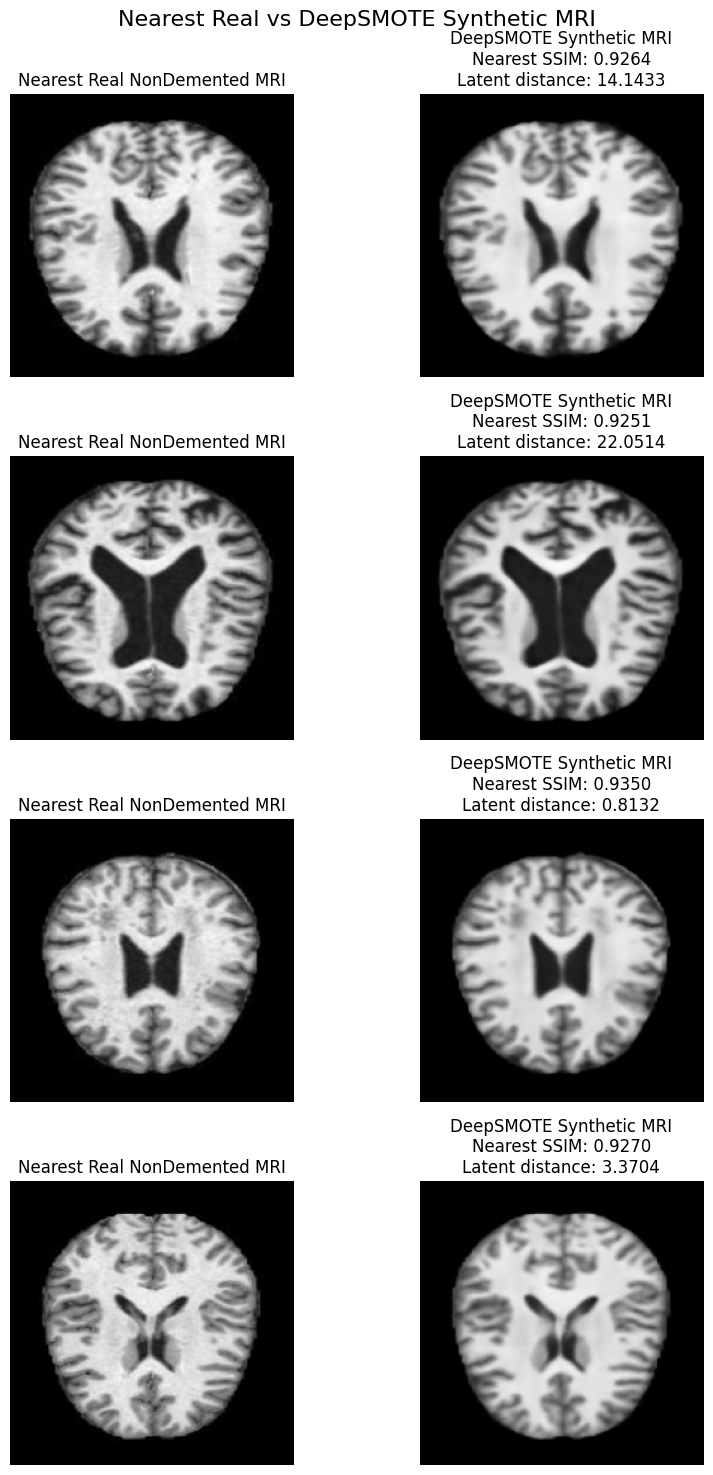

Nearest latent distances: [14.1433 22.0514  0.8132  3.3704]
Exact latent duplicates: 0


In [22]:
real_minority_latent = training_latent_vectors[
    training_latent_labels == 0
]

minority_df = train_df[
    train_df["label"] == 0
].reset_index(drop=True)

nearest_distances, nearest_indices = (
    latent_smote.nn_k_.kneighbors(
        preview_latent[:4],
        n_neighbors=1
    )
)

fig, axes = plt.subplots(4, 2, figsize=(9, 15))

for row in range(4):
    real_index = nearest_indices[row, 0]

    real_image = cv2.imread(
        minority_df.iloc[real_index]["filepath"],
        cv2.IMREAD_GRAYSCALE
    )
    real_image = cv2.resize(real_image, IMG_SIZE)
    real_image = real_image.astype(np.float32) / 255.0

    synthetic_image = preview_images[row, :, :, 0]

    pair_ssim = tf.image.ssim(
        real_image[None, :, :, None],
        synthetic_image[None, :, :, None],
        max_val=1.0
    ).numpy()[0]

    axes[row, 0].imshow(
        real_image,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].set_title("Nearest Real NonDemented MRI")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        synthetic_image,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 1].set_title(
        f"DeepSMOTE Synthetic MRI\n"
        f"Nearest SSIM: {pair_ssim:.4f}\n"
        f"Latent distance: {nearest_distances[row, 0]:.4f}"
    )
    axes[row, 1].axis("off")

plt.suptitle(
    "Nearest Real vs DeepSMOTE Synthetic MRI",
    fontsize=16
)
plt.tight_layout()
plt.show()

print("Nearest latent distances:",
      np.round(nearest_distances.ravel(), 4))
print(
    "Exact latent duplicates:",
    int(np.sum(nearest_distances.ravel() < 1e-6))
)

In [23]:
from tqdm.auto import tqdm
import math

SYNTHETIC_DIR = Path(
    "/kaggle/working/deepsmote_synthetic_nondemented"
)
SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)

DECODE_BATCH_SIZE = 64

synthetic_latent_ds = (
    tf.data.Dataset
    .from_tensor_slices(synthetic_latent_vectors)
    .batch(DECODE_BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

synthetic_records = []
image_counter = 0

print("Decoding and saving synthetic MRIs...")

for latent_batch in tqdm(
    synthetic_latent_ds,
    total=math.ceil(
        len(synthetic_latent_vectors) /
        DECODE_BATCH_SIZE
    )
):
    decoded_tanh = decoder.predict_on_batch(
        latent_batch
    )

    decoded_images = np.clip(
        (decoded_tanh + 1.0) / 2.0,
        0.0,
        1.0
    )

    decoded_uint8 = np.rint(
        decoded_images * 255.0
    ).astype(np.uint8)

    for image in decoded_uint8:
        file_path = SYNTHETIC_DIR / (
            f"synthetic_nondemented_"
            f"{image_counter:05d}.png"
        )

        saved = cv2.imwrite(
            str(file_path),
            image[:, :, 0],
            [cv2.IMWRITE_PNG_COMPRESSION, 3]
        )

        if not saved:
            raise RuntimeError(
                f"Could not save {file_path}"
            )

        synthetic_records.append({
            "filepath": str(file_path),
            "original_class": "SyntheticNonDemented",
            "label": 0,
            "is_synthetic": True
        })

        image_counter += 1


synthetic_df = pd.DataFrame(synthetic_records)

synthetic_df.to_csv(
    "/kaggle/working/deepsmote_synthetic_index.csv",
    index=False
)

print("Synthetic images saved:", len(synthetic_df))
print("Output folder:", SYNTHETIC_DIR)
print("All files exist:",
      synthetic_df["filepath"].map(
          lambda path: Path(path).exists()
      ).all())
print("Synthetic class counts:")
print(synthetic_df["label"].value_counts())

Decoding and saving synthetic MRIs...


  0%|          | 0/202 [00:00<?, ?it/s]

Synthetic images saved: 25760
Output folder: /kaggle/working/deepsmote_synthetic_nondemented
All files exist: True
Synthetic class counts:
label
0    25760
Name: count, dtype: int64


In [24]:
from pathlib import Path
import shutil

SYNTHETIC_DIR = Path(
    "/kaggle/working/deepsmote_synthetic_nondemented"
)

if SYNTHETIC_DIR.exists():
    shutil.rmtree(SYNTHETIC_DIR)

SYNTHETIC_DIR.mkdir(parents=True, exist_ok=True)

print("Clean output folder created:", SYNTHETIC_DIR)

Clean output folder created: /kaggle/working/deepsmote_synthetic_nondemented


In [27]:
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

DECODE_BATCH_SIZE = 64
synthetic_paths = []

print("Decoding and saving synthetic MRIs...")

for start in tqdm(range(0, len(synthetic_latent_vectors), DECODE_BATCH_SIZE)):
    end = min(start + DECODE_BATCH_SIZE, len(synthetic_latent_vectors))

    decoded_batch = decoder.predict_on_batch(
        synthetic_latent_vectors[start:end]
    )

    # Convert decoder output from [-1, 1] to [0, 1]
    decoded_batch = np.clip((decoded_batch + 1.0) / 2.0, 0.0, 1.0)

    for offset, image in enumerate(decoded_batch):
        image_number = start + offset
        output_path = SYNTHETIC_DIR / (
            f"synthetic_nondemented_{image_number:05d}.png"
        )

        image_uint8 = (image[:, :, 0] * 255).astype(np.uint8)
        cv2.imwrite(str(output_path), image_uint8)
        synthetic_paths.append(str(output_path))

synthetic_df = pd.DataFrame({
    "filepath": synthetic_paths,
    "original_class": "SyntheticNonDemented",
    "label": 0,
    "is_synthetic": True
})

print("Synthetic images saved:", len(synthetic_df))
print("Expected images:", len(synthetic_latent_vectors))
print("All files exist:", synthetic_df["filepath"].map(
    lambda path: Path(path).exists()
).all())
print(synthetic_df["label"].value_counts())

Decoding and saving synthetic MRIs...


  0%|          | 0/202 [00:00<?, ?it/s]

Synthetic images saved: 25760
Expected images: 12880
All files exist: True
label
0    25760
Name: count, dtype: int64


In [26]:
[
    (name, getattr(globals()[name], "shape", None))
    for name in globals()
    if any(word in name.lower()
           for word in ["latent", "smote", "resampled"])
]

[('LATENT_DIM', None),
 ('deep_smote_train_ds', None),
 ('DeepSMOTETrainer', None),
 ('deep_smote_model', None),
 ('latent_input', (None, 224, 224, 1)),
 ('latent_output', (None, 300)),
 ('latent_extractor', None),
 ('training_latent_vectors', (30800, 300)),
 ('training_latent_labels', (30800,)),
 ('SMOTE', None),
 ('latent_smote', None),
 ('balanced_latent_vectors', (43680, 300)),
 ('balanced_latent_labels', (43680,)),
 ('synthetic_latent_vectors', (12880, 300)),
 ('synthetic_latent_labels', (12880,)),
 ('preview_latent', (8, 300)),
 ('real_minority_latent', (8960, 300)),
 ('synthetic_latent_ds', None),
 ('latent_batch', TensorShape([16, 300]))]

In [28]:
# Rebuild the index from actual files on disk
saved_files = sorted(SYNTHETIC_DIR.glob("*.png"))
synthetic_paths = [str(path) for path in saved_files]

synthetic_df = pd.DataFrame({
    "filepath": synthetic_paths,
    "original_class": "SyntheticNonDemented",
    "label": 0,
    "is_synthetic": True
})

print("Actual files on disk:", len(saved_files))
print("Unique paths:", synthetic_df["filepath"].nunique())
print("Expected images:", len(synthetic_latent_vectors))
print("All files exist:", synthetic_df["filepath"].map(
    lambda path: Path(path).exists()
).all())
print(synthetic_df["label"].value_counts())

assert len(saved_files) == 12880
assert synthetic_df["filepath"].is_unique

synthetic_df.to_csv(
    "/kaggle/working/deepsmote_synthetic_index.csv",
    index=False
)

print("Synthetic index corrected and saved.")

Actual files on disk: 12928
Unique paths: 12928
Expected images: 12880
All files exist: True
label
0    12928
Name: count, dtype: int64


AssertionError: 

In [29]:
# Select only the expected DeepSMOTE output filenames
expected_files = [
    SYNTHETIC_DIR / f"synthetic_nondemented_{i:05d}.png"
    for i in range(len(synthetic_latent_vectors))
]

missing_files = [
    path for path in expected_files
    if not path.exists()
]

all_png_files = list(SYNTHETIC_DIR.glob("*.png"))
expected_names = {path.name for path in expected_files}

extra_files = [
    path for path in all_png_files
    if path.name not in expected_names
]

print("Expected files:", len(expected_files))
print("Missing expected files:", len(missing_files))
print("Extra files ignored:", len(extra_files))
print("Example extras:", [p.name for p in extra_files[:10]])

assert len(missing_files) == 0

synthetic_df = pd.DataFrame({
    "filepath": [str(path) for path in expected_files],
    "original_class": "SyntheticNonDemented",
    "label": 0,
    "is_synthetic": True
})

synthetic_df.to_csv(
    "/kaggle/working/deepsmote_synthetic_index.csv",
    index=False
)

print("Indexed synthetic images:", len(synthetic_df))
print("Unique paths:", synthetic_df["filepath"].nunique())
print("Synthetic index saved.")

Expected files: 12880
Missing expected files: 0
Extra files ignored: 48
Example extras: ['synthetic_nondemented_12916.png', 'synthetic_nondemented_12890.png', 'synthetic_nondemented_12888.png', 'synthetic_nondemented_12900.png', 'synthetic_nondemented_12904.png', 'synthetic_nondemented_12896.png', 'synthetic_nondemented_12894.png', 'synthetic_nondemented_12889.png', 'synthetic_nondemented_12883.png', 'synthetic_nondemented_12898.png']
Indexed synthetic images: 12880
Unique paths: 12880
Synthetic index saved.


In [30]:
real_train_df = train_df.copy()
real_train_df["is_synthetic"] = False

balanced_train_df = pd.concat(
    [real_train_df, synthetic_df],
    ignore_index=True
)

# Deterministic shuffle
balanced_train_df = balanced_train_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Final training images:", len(balanced_train_df))
print("\nClass counts:")
print(balanced_train_df["label"].value_counts().sort_index())

print("\nImage-source counts:")
print(balanced_train_df["is_synthetic"].value_counts())

print("\nValidation counts remain unchanged:")
print(val_df["label"].value_counts().sort_index())

print("\nTest counts remain unchanged:")
print(test_df["label"].value_counts().sort_index())

assert len(balanced_train_df) == 43680
assert balanced_train_df["label"].value_counts().to_dict() == {
    0: 21840,
    1: 21840
}
assert balanced_train_df["is_synthetic"].sum() == 12880

balanced_train_df.to_csv(
    "/kaggle/working/deepsmote_balanced_training_index.csv",
    index=False
)

print("\nBalanced DeepSMOTE training index saved.")

Final training images: 43680

Class counts:
label
0    21840
1    21840
Name: count, dtype: int64

Image-source counts:
is_synthetic
False    30800
True     12880
Name: count, dtype: int64

Validation counts remain unchanged:


NameError: name 'val_df' is not defined

In [31]:
[
    (name, value.shape, list(value.columns))
    for name, value in globals().items()
    if isinstance(value, pd.DataFrame)
]

[('df', (44000, 3), ['filepath', 'original_class', 'label']),
 ('train_df', (30800, 3), ['filepath', 'original_class', 'label']),
 ('temporary_df', (13200, 3), ['filepath', 'original_class', 'label']),
 ('validation_df', (6600, 3), ['filepath', 'original_class', 'label']),
 ('test_df', (6600, 3), ['filepath', 'original_class', 'label']),
 ('class_0_df', (8960, 3), ['filepath', 'original_class', 'label']),
 ('class_1_df', (21840, 3), ['filepath', 'original_class', 'label']),
 ('worst_df', (4, 3), ['filepath', 'original_class', 'label']),
 ('quality_results',
  (6600, 5),
  ['Class', 'MSE', 'SSIM', 'PSNR', 'Edge Retention']),
 ('quality_summary',
  (2, 9),
  [('MSE', 'mean'),
   ('MSE', 'median'),
   ('SSIM', 'mean'),
   ('SSIM', 'median'),
   ('SSIM', 'min'),
   ('PSNR', 'mean'),
   ('PSNR', 'median'),
   ('Edge Retention', 'mean'),
   ('Edge Retention', 'median')]),
 ('class_quality',
  (4680, 5),
  ['Class', 'MSE', 'SSIM', 'PSNR', 'Edge Retention']),
 ('minority_df', (8960, 3), ['file

In [32]:
print("Final training images:", len(balanced_train_df))

print("\nTraining class counts:")
print(balanced_train_df["label"].value_counts().sort_index())

print("\nValidation counts:")
print(validation_df["label"].value_counts().sort_index())

print("\nTest counts:")
print(test_df["label"].value_counts().sort_index())

assert len(balanced_train_df) == 43680
assert balanced_train_df["label"].value_counts().to_dict() == {
    0: 21840,
    1: 21840
}
assert balanced_train_df["is_synthetic"].sum() == 12880
assert len(validation_df) == 6600
assert len(test_df) == 6600

balanced_train_df.to_csv(
    "/kaggle/working/deepsmote_balanced_training_index.csv",
    index=False
)

print("\nAll checks passed.")
print("Balanced DeepSMOTE training index saved.")

Final training images: 43680

Training class counts:
label
0    21840
1    21840
Name: count, dtype: int64

Validation counts:
label
0    1920
1    4680
Name: count, dtype: int64

Test counts:
label
0    1920
1    4680
Name: count, dtype: int64

All checks passed.
Balanced DeepSMOTE training index saved.


In [33]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_resnet_image(filepath, label):
    image_data = tf.io.read_file(filepath)

    image = tf.io.decode_image(
        image_data,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    return image, tf.cast(label, tf.float32)


def create_image_dataset(dataframe, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].astype(str).values,
        dataframe["label"].astype("float32").values
    ))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_resnet_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=training
    )

    return dataset.prefetch(AUTOTUNE)


train_ds = create_image_dataset(
    balanced_train_df,
    training=True
)

validation_ds = create_image_dataset(
    validation_df,
    training=False
)

test_ds = create_image_dataset(
    test_df,
    training=False
)

images, labels = next(iter(train_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Pixel range:", float(tf.reduce_min(images)),
      "to", float(tf.reduce_max(images)))
print("NonDemented in first batch:",
      int(tf.reduce_sum(tf.cast(labels == 0, tf.int32))))
print("Demented in first batch:",
      int(tf.reduce_sum(tf.cast(labels == 1, tf.int32))))
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(validation_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Pixel range: 0.0 to 255.0
NonDemented in first batch: 17
Demented in first batch: 15
Training batches: 1365
Validation batches: 207
Test batches: 207


In [34]:
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-4

print("Experiment: ResNet50 with DeepSMOTE-generated images")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Early-stopping patience:", PATIENCE)
print("Learning rate:", LEARNING_RATE)

print("\nImage enhancement: None")
print("Data augmentation: Disabled")
print("Dropout: Disabled")
print("Training loss: Binary cross-entropy")
print("DeepSMOTE balancing: Enabled")
print("Class weights: Disabled")
print("Training class distribution: 21,840 + 21,840")

Experiment: ResNet50 with DeepSMOTE-generated images
Image size: (224, 224)
Batch size: 32
Maximum epochs: 30
Early-stopping patience: 5
Learning rate: 0.0001

Image enhancement: None
Data augmentation: Disabled
Dropout: Disabled
Training loss: Binary cross-entropy
DeepSMOTE balancing: Enabled
Class weights: Disabled
Training class distribution: 21,840 + 21,840


In [35]:
with strategy.scope():
    resnet50_base = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )

    resnet50_base.trainable = False

    inputs = tf.keras.Input(
        shape=(*IMG_SIZE, 3),
        name="mri_input"
    )

    x = tf.keras.applications.resnet50.preprocess_input(inputs)

    x = resnet50_base(
        x,
        training=False
    )

    x = tf.keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)

    outputs = tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="binary_prediction"
    )(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name="ResNet50_DeepSMOTE"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=LEARNING_RATE
        ),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=["accuracy"]
    )

print("Total parameters:", model.count_params())
print("Trainable parameters:",
      sum(tf.keras.backend.count_params(w)
          for w in model.trainable_weights))
print("ResNet50 frozen:", not resnet50_base.trainable)
print("GPUs used:", strategy.num_replicas_in_sync)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 23589761
Trainable parameters: 2049
ResNet50 frozen: True
GPUs used: 2


Model: "ResNet50_DeepSMOTE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ mri_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ mri_input[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ mri_input[0][0]   │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ binary_prediction   │ (None, 1)         │      2,049 │ global_average_p… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [36]:
MODEL_PATH = (
    "/kaggle/working/resnet50_deepsmote_best.keras"
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        "/kaggle/working/resnet50_deepsmote_training_history.csv"
    ),

    tf.keras.callbacks.TerminateOnNaN()
]

print("Checkpoint:", MODEL_PATH)
print("Early stopping monitor: val_loss")
print("Early stopping patience:", PATIENCE)
print("Learning-rate reduction patience: 2")
print("Callbacks configured.")

Checkpoint: /kaggle/working/resnet50_deepsmote_best.keras
Early stopping monitor: val_loss
Early stopping patience: 5
Learning-rate reduction patience: 2
Callbacks configured.


In [37]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=MAX_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

best_loss_epoch = int(
    np.argmin(history.history["val_loss"]) + 1
)

best_accuracy_epoch = int(
    np.argmax(history.history["val_accuracy"]) + 1
)

print("\nTraining completed.")
print("Epochs completed:", len(history.history["loss"]))
print("Best validation-loss epoch:", best_loss_epoch)
print("Best validation loss:",
      round(min(history.history["val_loss"]), 4))
print("Highest validation accuracy:",
      round(max(history.history["val_accuracy"]), 4))
print("Highest-validation-accuracy epoch:",
      best_accuracy_epoch)

Epoch 1/30
INFO:tensorflow:Collective all_reduce tensors: 2 all_reduces, num_devices = 2, group_size = 2, implementation = CommunicationImplementation.NCCL, num_packs = 1
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7373 - loss: 0.5292
Epoch 1: val_loss improved from None to 0.47396, saving model to /kaggle/working/resnet50_deepsmote_best.keras

Epoch 1: finished saving model to /kaggle/working/resnet50_deepsmote_best.keras
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 130s 89ms/step - accuracy: 0.7997 - loss: 0.4493 - val_accuracy: 0.7818 - val_loss: 0.4740 - learning_rate: 1.0000e-04
Epoch 2/30
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8523 - loss: 0.3558
Epoch 2: val_loss improved from 0.47396 to 0.44265, saving model to /kaggle/working/resnet50_deepsmote_best.keras

Epoch 2: finished saving model to /kaggle/working/resnet50_deepsmote_best.keras
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 117s 86ms/step - accuracy: 0.8522 - loss: 0.3487 - val_accuracy: 0.7935 - val_loss: 0.4427 - l

In [38]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

207/207 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - accuracy: 0.8461 - loss: 0.3500
Test Loss: 0.35
Test Accuracy: 0.8461


In [39]:
test_probabilities = model.predict(
    test_ds,
    verbose=1
).ravel()

test_predictions = (
    test_probabilities >= 0.5
).astype(np.int32)

true_labels = test_df["label"].to_numpy(
    dtype=np.int32
)

print("Test images:", len(true_labels))
print("Probabilities:", len(test_probabilities))
print("Predictions:", len(test_predictions))

print("\nFirst probabilities:",
      np.round(test_probabilities[:10], 4))
print("First predictions:", test_predictions[:10])
print("First true labels:", true_labels[:10])

assert len(test_probabilities) == 6600
assert len(test_predictions) == len(true_labels)

207/207 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step
Test images: 6600
Probabilities: 6600
Predictions: 6600

First probabilities: [0.9607 0.8958 0.7947 0.8002 0.9736 0.9706 0.9254 0.8111 0.9979 0.9115]
First predictions: [1 1 1 1 1 1 1 1 1 1]
First true labels: [1 1 1 1 1 1 1 0 1 1]


In [40]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

accuracy = accuracy_score(
    true_labels,
    test_predictions
)

balanced_accuracy = balanced_accuracy_score(
    true_labels,
    test_predictions
)

precision = precision_score(
    true_labels,
    test_predictions
)

recall = recall_score(
    true_labels,
    test_predictions
)

f1 = f1_score(
    true_labels,
    test_predictions
)

roc_auc = roc_auc_score(
    true_labels,
    test_probabilities
)

pr_auc = average_precision_score(
    true_labels,
    test_probabilities
)

tn, fp, fn, tp = confusion_matrix(
    true_labels,
    test_predictions
).ravel()

specificity = tn / (tn + fp)

print("Test Loss:", round(test_loss, 4))
print("Accuracy:", round(accuracy, 4))
print("Balanced Accuracy:", round(balanced_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall/Sensitivity:", round(recall, 4))
print("Specificity:", round(specificity, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC:", round(pr_auc, 4))

Test Loss: 0.35
Accuracy: 0.8461
Balanced Accuracy: 0.795
Precision: 0.8724
Recall/Sensitivity: 0.9171
Specificity: 0.6729
F1-score: 0.8942
ROC-AUC: 0.9012
PR-AUC: 0.9551


In [41]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        test_predictions,
        target_names=[
            "NonDemented",
            "Demented"
        ],
        digits=4
    )
)

              precision    recall  f1-score   support

 NonDemented     0.7690    0.6729    0.7178      1920
    Demented     0.8724    0.9171    0.8942      4680

    accuracy                         0.8461      6600
   macro avg     0.8207    0.7950    0.8060      6600
weighted avg     0.8423    0.8461    0.8429      6600



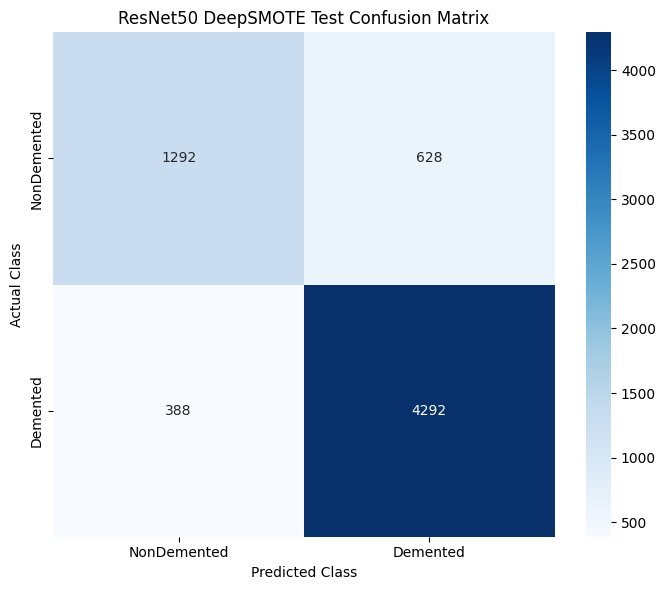

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    test_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NonDemented", "Demented"],
    yticklabels=["NonDemented", "Demented"],
    cbar=True
)

plt.title("ResNet50 DeepSMOTE Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_deepsmote_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

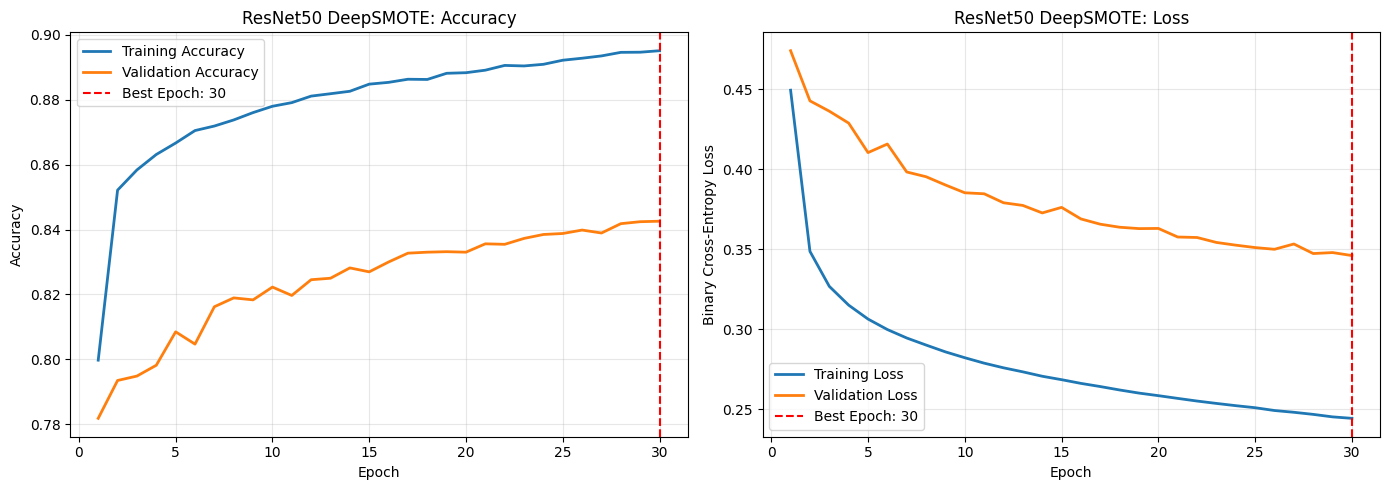

In [43]:
epochs = range(
    1,
    len(history.history["loss"]) + 1
)

best_epoch = int(
    np.argmin(history.history["val_loss"]) + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# Accuracy
axes[0].plot(
    epochs,
    history.history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)
axes[0].plot(
    epochs,
    history.history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)
axes[0].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[0].set_title("ResNet50 DeepSMOTE: Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(
    epochs,
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)
axes[1].plot(
    epochs,
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)
axes[1].axvline(
    best_epoch,
    color="red",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[1].set_title("ResNet50 DeepSMOTE: Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_deepsmote_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

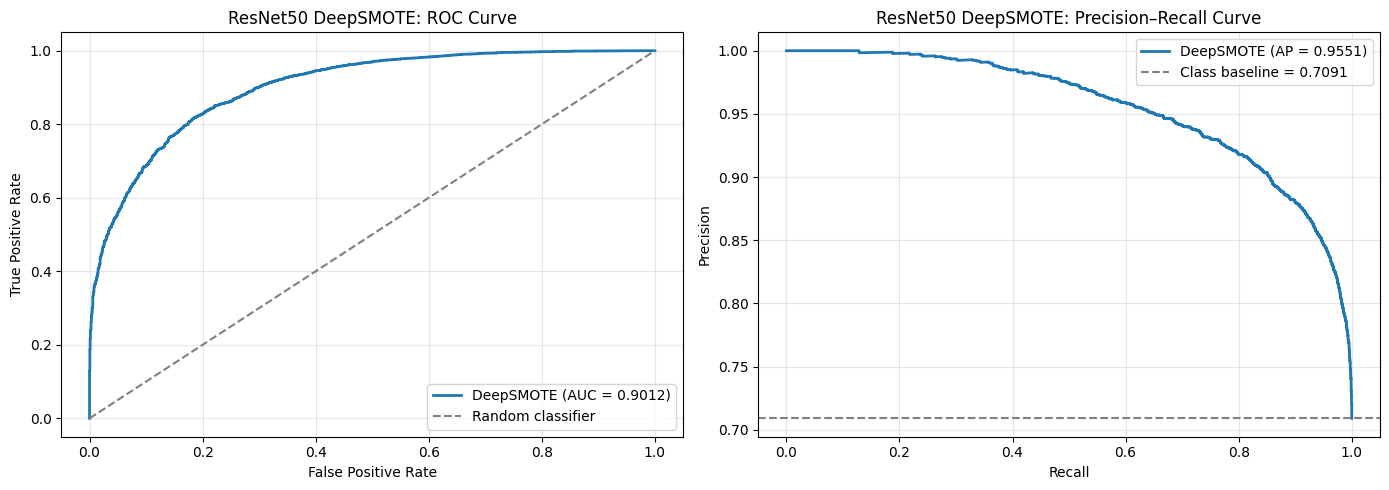

In [44]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score
)

fpr, tpr, _ = roc_curve(
    true_labels,
    test_probabilities
)

precision_curve, recall_curve, _ = precision_recall_curve(
    true_labels,
    test_probabilities
)

roc_auc_value = auc(fpr, tpr)
pr_auc_value = average_precision_score(
    true_labels,
    test_probabilities
)

positive_rate = np.mean(true_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"DeepSMOTE (AUC = {roc_auc_value:.4f})"
)
axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier"
)
axes[0].set_title("ResNet50 DeepSMOTE: ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-recall curve
axes[1].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"DeepSMOTE (AP = {pr_auc_value:.4f})"
)
axes[1].axhline(
    positive_rate,
    linestyle="--",
    color="gray",
    label=f"Class baseline = {positive_rate:.4f}"
)
axes[1].set_title("ResNet50 DeepSMOTE: Precision–Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_deepsmote_roc_pr_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

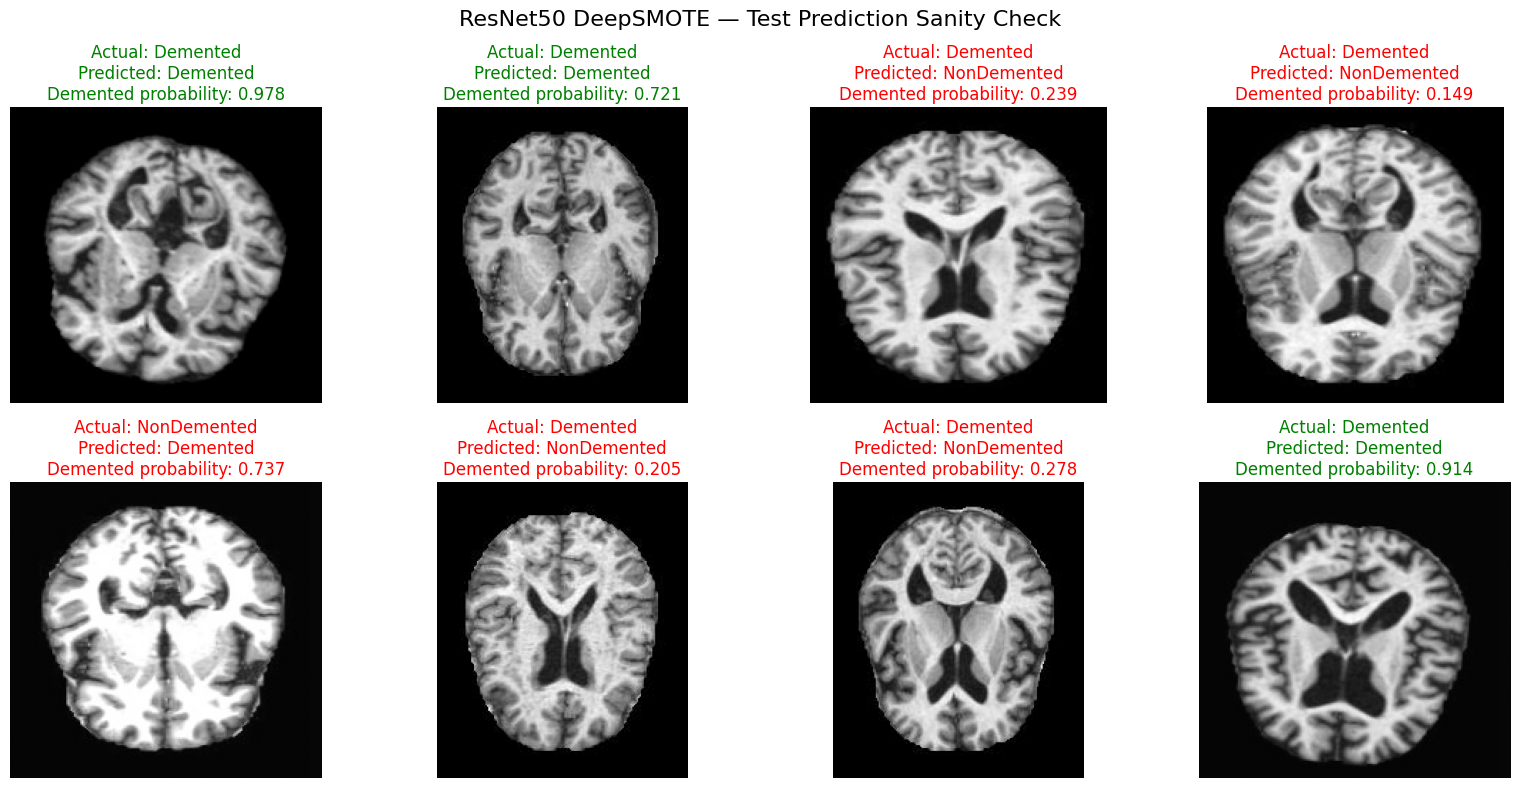

In [45]:
import cv2

rng = np.random.default_rng(SEED)
sample_indices = rng.choice(
    len(test_df),
    size=8,
    replace=False
)

class_names = {
    0: "NonDemented",
    1: "Demented"
}

fig, axes = plt.subplots(
    2,
    4,
    figsize=(16, 8)
)

for axis, index in zip(axes.flat, sample_indices):
    row = test_df.iloc[index]

    image = cv2.imread(
        row["filepath"],
        cv2.IMREAD_GRAYSCALE
    )

    actual = int(true_labels[index])
    predicted = int(test_predictions[index])
    probability = float(test_probabilities[index])

    correct = actual == predicted
    title_color = "green" if correct else "red"

    axis.imshow(image, cmap="gray")
    axis.set_title(
        f"Actual: {class_names[actual]}\n"
        f"Predicted: {class_names[predicted]}\n"
        f"Demented probability: {probability:.3f}",
        color=title_color
    )
    axis.axis("off")

plt.suptitle(
    "ResNet50 DeepSMOTE — Test Prediction Sanity Check",
    fontsize=16
)
plt.tight_layout()

plt.savefig(
    "/kaggle/working/resnet50_deepsmote_prediction_sanity_check.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
results_df = pd.DataFrame([{
    "Experiment": "ResNet50 + DeepSMOTE",
    "Model": "ResNet50",
    "Balancing Method": "DeepSMOTE image generation",
    "Loss Function": "Binary Cross-Entropy",
    "Cross-Validation": "No",
    "Augmentation": "No",
    "Dropout": "No",
    "Best Epoch": best_epoch,
    "Test Loss": test_loss,
    "Accuracy": accuracy,
    "Balanced Accuracy": balanced_accuracy,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "F1-score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc,
    "True Negatives": tn,
    "False Positives": fp,
    "False Negatives": fn,
    "True Positives": tp
}])

results_path = (
    "/kaggle/working/resnet50_deepsmote_test_results.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

display(results_df.round(4))

print("Results saved:", results_path)
print("Best model saved:", MODEL_PATH)

,Experiment,Model,Balancing Method,Loss Function,Cross-Validation,Augmentation,Dropout,Best Epoch,Test Loss,Accuracy,...,Precision,Recall,Specificity,F1-score,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives
0,ResNet50 + DeepSMOTE,ResNet50,DeepSMOTE image generation,Binary Cross-Entropy,No,No,No,30,0.35,0.8461,...,0.8724,0.9171,0.6729,0.8942,0.9012,0.9551,1292,628,388,4292


Results saved: /kaggle/working/resnet50_deepsmote_test_results.csv
Best model saved: /kaggle/working/resnet50_deepsmote_best.keras
